# <center>**Projet IA**

# Importation des bibliothèques

In [54]:
# Pour lire et manipuler les données
import pandas as pd 
# Pour les calculs mathématiques
import numpy as np
# Diviser les données (train/test)
from sklearn.model_selection import train_test_split
# Permet de normaliser les données
from sklearn.preprocessing import StandardScaler
# Algorithme KNN (classification)
from sklearn.neighbors import KNeighborsClassifier
# Algorithme de clustering
from sklearn.cluster import KMeans
# Pour mesurer la performance
from sklearn.metrics import accuracy_score
# Pour faire des graphiques
import matplotlib.pyplot as plt

# Chargement des données

In [55]:
df = pd.read_csv("Carseats.csv") # Charger le dataset
df.head() # Afficher les 5 premières lignes

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


# 1 KNN — Apprentissage supervisé

In [56]:
# Classer les magasins en deux cat ́egories
df["High"] = (df["Sales"] > 8).astype(int) # si sales > 8 alors High = 1 sinon High = 0
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0


# 1.2 Préparation des données

In [57]:
# On définit 'X' (les variables explicatives) en supprimant la cible 'High' et la valeur brute 'Sales'
X = df.drop(columns=["Sales", "High"])

y = df["High"]

# Encodage des variables qualitatives en transformant tes colonnes de texte (variables qualitatives) en colonnes de chiffres (0 et 1)
X = pd.get_dummies(X, drop_first=True)
X

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,138,73,11,276,120,42,17,False,False,True,True
1,111,48,16,260,83,65,10,True,False,True,True
2,113,35,10,269,80,59,12,False,True,True,True
3,117,100,4,466,97,55,14,False,True,True,True
4,141,64,3,340,128,38,13,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128,33,14,True,False,True,True
396,139,23,3,37,120,55,11,False,True,False,True
397,162,26,12,368,159,40,18,False,True,True,True
398,100,79,7,284,95,50,12,False,False,True,True


# 1.3 Séparation apprentissage / test

In [58]:
# On divise les données en 4 groupes : 
# X_train / y_train : le modèle apprend ici
# X_test / y_test : On vérifie si le modèle a compris
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, # On réserve 30% des données pour le test et 70% servent à l'entraînement
    random_state=0 # Fixe le hasard pour avoir le même mélange à chaque exécution
)

# 1.4 Normalisation

In [59]:
# On crée l'outil de normalisation (le Scaler)
scaler = StandardScaler()

# On "apprend" et on transforme les données d'entraînement
# 'fit' calcule la moyenne et l'écart-type de chaque colonne de X_train
# 'transform' applique la formule pour centrer les données sur 0
X_train_scaled = scaler.fit_transform(X_train)

# On transforme les données de test
# pour traiter le test exactement comme le train, sans "tricher" => des informations que le modèle ne devrait pas connaître à l'avance
X_test_scaled = scaler.transform(X_test)

# 1.5 Entrainement du modle KNN

In [60]:
# le modèle regardera les 5 voisins les plus proches de lui
model = KNeighborsClassifier(n_neighbors=5)
# On donne au modèle les données d'entraînement normalisées (X) et les bonnes réponses correspondantes (y)
model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# 1.6 Evaluation

In [61]:
# Le modèle prédit les valeurs pour le test
y_pred = model.predict(X_test_scaled)
# Accuracy
print("Accuracy =", accuracy_score(y_test, y_pred))

Accuracy = 0.7666666666666667


# 1.6.1 Evaluation avec différentes valeurs de K

In [62]:
for k in [1, 3, 5, 7, 9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    print("Pour k =", k, "Accuracy =", accuracy_score(y_test, y_pred))

Pour k = 1 Accuracy = 0.7583333333333333
Pour k = 3 Accuracy = 0.7666666666666667
Pour k = 5 Accuracy = 0.7666666666666667
Pour k = 7 Accuracy = 0.75
Pour k = 9 Accuracy = 0.7666666666666667


Après avoir testé plusieurs valeurs de k (1, 3, 5, 7, 9), nous avons observé que les meilleures performances sont obtenues pour k = 3, 5 et 9 avec une accuracy d’environ **76.66%**, Nous choisissons **k = 5** car il offre un bon compromis entre **stabilité** et **précision**.

# 2 K-means — Apprentissage non supervisé

# 2.1 Préparation des données

In [63]:
X_cluster = df.drop(columns=["Sales", "High"])
# K-Means ne doit PAS utiliser de réponse (y) sinon ce n’est plus non supervisé
# Transformer les variables texte en nombres
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# La Normalisation
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# 2.2 Entrainer K-means (k = 3)

In [64]:
# On veut créer 3 groupes
kmeans = KMeans(n_clusters=3, random_state=0)
# Apprendre les groupes Assigner chaque point à un cluster
clusters = kmeans.fit_predict(X_cluster_scaled)
# Ajouter le résultat dans le dataset
# Maintenant chaque ligne a un groupe
df["Cluster"] = clusters
# Verification
df.head()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,2


# 2.3 Visualisation simple

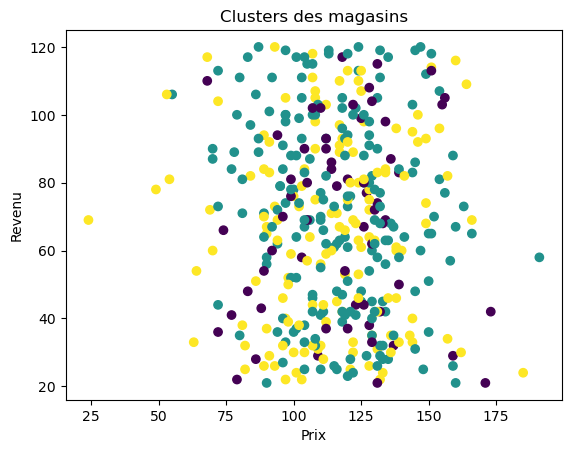

In [65]:
# dessine un graphique (nuage de points)
plt.scatter(df["Price"], df["Income"], c=df["Cluster"])
# Ajoute labels + affiche graphique
plt.xlabel("Prix")
plt.ylabel("Revenu")
plt.title("Clusters des magasins")
plt.show()

Les points ne sont pas **clairement séparés**, car les clusters sont mélangés sur le graphique.

# 2.4 Test avec (k = 2)

In [67]:
# On veut créer 2 groupes
kmeans = KMeans(n_clusters=2, random_state=0)
# Apprendre les groupes Assigner chaque point à un cluster
clusters = kmeans.fit_predict(X_cluster_scaled)
# Ajouter le résultat dans le dataset
# Maintenant chaque ligne a un groupe
df["Cluster"] = clusters
# Verification
df.head()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,0
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1


# Visualisation simple

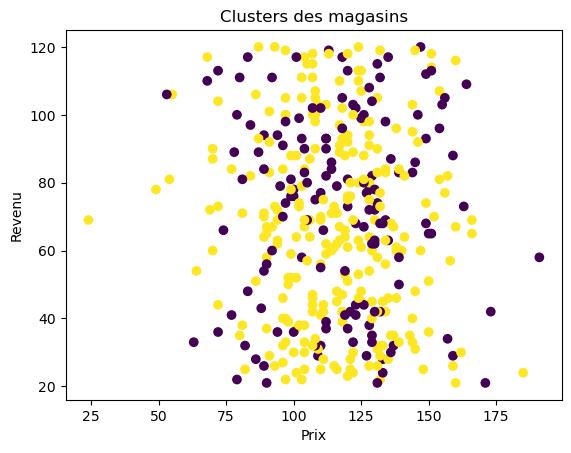

In [68]:
# Dessiner un graphique (nuage de points)
plt.scatter(df["Price"], df["Income"], c=df["Cluster"])
# Ajoute labels + affiche graphique
plt.xlabel("Prix")
plt.ylabel("Revenu")
plt.title("Clusters des magasins")
plt.show()

# 2.3 Test avec (k = 4)

In [ ]:
# On veut créer 4 groupes
kmeans = KMeans(n_clusters=2, random_state=0)
# Apprendre les groupes Assigner chaque point à un cluster
clusters = kmeans.fit_predict(X_cluster_scaled)
# Ajouter le résultat dans le dataset
# Maintenant chaque ligne a un groupe
df["Cluster"] = clusters
# Verification
df.head()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,0
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1


# Visualisation simple k = 4

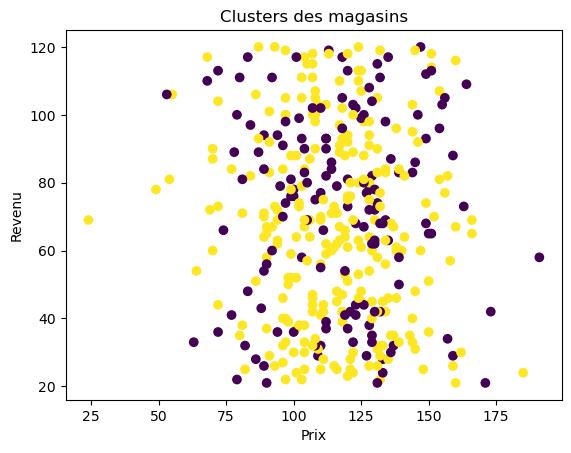

In [70]:
# Dessiner un graphique (nuage de points)
plt.scatter(df["Price"], df["Income"], c=df["Cluster"])
# Ajoute labels + affiche graphique
plt.xlabel("Prix")
plt.ylabel("Revenu")
plt.title("Clusters des magasins")
plt.show()